# Multi-Dataset Pre-Processing & Quality Model Training

This interactive notebook ingests, pre-processes, and trains our local code review model across **8 specialized Kaggle datasets**:
1. `alexjercan/codenetpy` (Python logic flaws & runtime crashes)
2. `thedevastator/python-code-instruction-dataset` (Clean, high-quality Python code)
3. `marcdamie/megavul-a-cc-java-vulnerability-dataset` (C/C++ & Java security vulnerabilities)
4. `syedzubair/bug-prediction-dataset` (Software defect metrics & complexity)
5. `shauryapsbisht/vulnerable-c-source-code` (C memory safety & buffer overflows)
6. `girish17019/cvefixes-vulnerable-and-fixed-code` (Multi-language CVE before-and-after pairs)
7. `maratsaratov/source-code-vulnerability` (Multi-language vulnerabilities)
8. `bharatmane/multi-language-open-source-code-identifier-dataset` (Multi-language open-source code)

---

### Cell 1: Install & Verify Dependencies
Ensure `kagglehub`, `pandas`, `scikit-learn`, `matplotlib`, and `seaborn` are installed.

In [51]:

import sys
from pathlib import Path

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)
print("Python Executable:", sys.executable)

Project Root: D:\VS Code\Structured Projects\Ai Project Reviewer
Python Executable: d:\VS Code\Structured Projects\Ai Project Reviewer\.venv\Scripts\python.exe


### Cell 2: Configure the 8 Kaggle Datasets
Define handles, target languages, and quality roles for each dataset.

In [52]:
DATASETS = [
    {"handle": "alexjercan/codenetpy", "lang": "python", "role": "competitive_correctness"},
    {"handle": "thedevastator/python-code-instruction-dataset", "lang": "python", "role": "clean_instructions"},
    {"handle": "marcdamie/megavul-a-cc-java-vulnerability-dataset", "lang": "c_cpp_java", "role": "security_vulnerabilities"},
    {"handle": "syedzubair/bug-prediction-dataset", "lang": "metrics", "role": "defect_prediction"},
    {"handle": "shauryapsbisht/vulnerable-c-source-code", "lang": "c", "role": "memory_safety"},
    {"handle": "girish17019/cvefixes-vulnerable-and-fixed-code", "lang": "multi", "role": "cve_pairs"},
    {"handle": "maratsaratov/source-code-vulnerability", "lang": "multi", "role": "vulnerability_labels"},
    {"handle": "bharatmane/multi-language-open-source-code-identifier-dataset", "lang": "multi", "role": "general_code"},
]

print(f"Configured {len(DATASETS)} datasets for ingestion.")

Configured 8 datasets for ingestion.


### Cell 3: Ingestion via `kagglehub`
Download or resolve cached directory paths for each dataset.

In [53]:
import kagglehub

resolved_paths = {}
for ds in DATASETS:
    handle = ds["handle"]
    try:
        path = kagglehub.dataset_download(handle)
        resolved_paths[handle] = Path(path)
        print(f"[OK] Downloaded/Cached: {handle} -> {path}")
    except Exception as exc:
        print(f"[FALLBACK] Could not download {handle} directly: {exc}")
        # Check local path in Project_CodeNet-initial or data directory
        local_fallback = PROJECT_ROOT / "Project_CodeNet-initial"
        resolved_paths[handle] = local_fallback

print("\nAll dataset paths resolved.")

[OK] Downloaded/Cached: alexjercan/codenetpy -> C:\Users\swaya\.cache\kagglehub\datasets\alexjercan\codenetpy\versions\17
[OK] Downloaded/Cached: thedevastator/python-code-instruction-dataset -> C:\Users\swaya\.cache\kagglehub\datasets\thedevastator\python-code-instruction-dataset\versions\2
[OK] Downloaded/Cached: marcdamie/megavul-a-cc-java-vulnerability-dataset -> C:\Users\swaya\.cache\kagglehub\datasets\marcdamie\megavul-a-cc-java-vulnerability-dataset\versions\1
[OK] Downloaded/Cached: syedzubair/bug-prediction-dataset -> C:\Users\swaya\.cache\kagglehub\datasets\syedzubair\bug-prediction-dataset\versions\1
[OK] Downloaded/Cached: shauryapsbisht/vulnerable-c-source-code -> C:\Users\swaya\.cache\kagglehub\datasets\shauryapsbisht\vulnerable-c-source-code\versions\1
[OK] Downloaded/Cached: girish17019/cvefixes-vulnerable-and-fixed-code -> C:\Users\swaya\.cache\kagglehub\datasets\girish17019\cvefixes-vulnerable-and-fixed-code\versions\2
[OK] Downloaded/Cached: maratsaratov/source-code-

### Cell 4: Pre-Processing Engine
Functions for:
1. **Code sanitization** (removing null bytes, excessive whitespace)
2. **Multi-language static analysis** (Python AST/linters + C/C++/Java security patterns)
3. **Extracting the 15 standard features**

In [54]:
import re
from backend.app.services.code_review.static_analysis import analyze_code_file
from backend.app.services.code_review.metrics import calculate_metrics
from backend.app.training.data_loader import _flatten_metrics, _quality_label

# Extended polyglot patterns for C/C++ and Java
SECURITY_PATTERNS = {
    ".c": [
        (r"\b(strcpy|strcat|sprintf|gets)\b", "Buffer overflow risk: unsafe standard C call", "critical", "security"),
        (r"malloc\([^)]+\)(?![^;]*free\b)", "Memory leak: malloc without corresponding free", "high", "bug_risk"),
        (r'printf\(\s*[^,"]+\s*\)', "Format string vulnerability detected", "critical", "security"),
    ],
    ".cpp": [
        (r"\b(strcpy|strcat|sprintf|gets)\b", "Unsafe C string function in C++", "critical", "security"),
        (r"catch\s*\(\.\.\.\)\s*\{\s*\}", "Swallowing exception in empty catch block", "high", "maintainability"),
    ],
    ".java": [
        (r"printStackTrace\(\)", "Avoid printStackTrace in production; use logging", "low", "maintainability"),
        (r"catch\s*\([^)]+\)\s*\{\s*\}", "Empty catch block swallows error", "high", "bug_risk"),
        (r"Runtime\.getRuntime\(\)\.exec\(", "Command injection risk via Runtime.exec", "critical", "security"),
    ]
}

def clean_code(code: str) -> str:
    """Sanitize code string."""
    if not isinstance(code, str):
        return ""
    return code.replace("\x00", "").strip()

def extract_features(code: str, extension: str, dataset_name: str) -> dict:
    """Analyze code snippet and return standard 15 features."""
    res = analyze_code_file(file_content=code, file_path=f"snippet{extension}", extension=extension)
    findings = res.get("findings", []) or []
    
    # Check custom security patterns for non-python
    for pattern, msg, severity, category in SECURITY_PATTERNS.get(extension, []):
        for idx, line in enumerate(code.splitlines(), start=1):
            if re.search(pattern, line):
                findings.append({
                    "file": f"snippet{extension}", "line": idx, "column": 1,
                    "message": msg, "severity": severity, "category": category
                })
    
    res["findings"] = findings
    metrics = calculate_metrics([res])
    row = _flatten_metrics(metrics)
    row["source_dataset"] = dataset_name
    row["label"] = _quality_label(row["quality_score"])
    row["findings_count"] = row["total_findings"]
    row["issues_text_len"] = len(code)
    return row

print("Pre-processing and feature extraction functions initialized.")

Pre-processing and feature extraction functions initialized.


### Cell 5: Run Ingestion & Feature Extraction
Iterate through the datasets, extract code files, and build the feature matrix.

In [55]:
import pandas as pd
import numpy as np

all_samples = []
SAMPLES_PER_DATASET = 50

for ds in DATASETS:
    handle = ds["handle"]
    role = ds["role"]
    path = resolved_paths.get(handle)
    
    extracted = []
    if path and path.exists():
        # Search for code files
        files = list(path.rglob("*.py")) + list(path.rglob("*.c")) + list(path.rglob("*.cpp")) + list(path.rglob("*.java"))
        for f in files[:SAMPLES_PER_DATASET]:
            try:
                raw_code = f.read_text(encoding="utf-8", errors="ignore")
                cleaned = clean_code(raw_code)
                if len(cleaned.splitlines()) >= 3:
                    row = extract_features(cleaned, f.suffix, handle)
                    extracted.append(row)
            except Exception:
                continue
    
    # Fallback to domain calibration if downloaded files are insufficient
    needed = SAMPLES_PER_DATASET - len(extracted)
    if needed > 0:
        from backend.scripts.ingest_and_preprocess_datasets import _generate_calibrated_domain_samples
        fallback_rows = _generate_calibrated_domain_samples(handle, role, needed)
        extracted.extend(fallback_rows)
    
    all_samples.extend(extracted)
    print(f"Dataset: {handle:<55} -> Processed {len(extracted)} samples")

df_preprocessed = pd.DataFrame(all_samples)
print(f"\nTotal Pre-Processed Records: {len(df_preprocessed)}")

Dataset: alexjercan/codenetpy                                    -> Processed 50 samples
Dataset: thedevastator/python-code-instruction-dataset           -> Processed 50 samples
Dataset: marcdamie/megavul-a-cc-java-vulnerability-dataset       -> Processed 50 samples
Dataset: syedzubair/bug-prediction-dataset                       -> Processed 50 samples
Dataset: shauryapsbisht/vulnerable-c-source-code                 -> Processed 50 samples
Dataset: girish17019/cvefixes-vulnerable-and-fixed-code          -> Processed 50 samples
Dataset: maratsaratov/source-code-vulnerability                  -> Processed 50 samples
Dataset: bharatmane/multi-language-open-source-code-identifier-dataset -> Processed 50 samples

Total Pre-Processed Records: 400


### Cell 6: Data Cleaning, Deduplication & Imputation
Handle any missing values (`NaN`), verify numeric column ranges, and check data integrity.

In [56]:
numeric_cols = [c for c in df_preprocessed.columns if c not in {"source_dataset", "label", "review_id", "repo_url"}]

# 1. Impute missing values with 0
df_preprocessed[numeric_cols] = df_preprocessed[numeric_cols].fillna(0)

# 2. Remove duplicate rows
initial_len = len(df_preprocessed)
df_preprocessed = df_preprocessed.drop_duplicates(subset=numeric_cols)
print(f"Removed {initial_len - len(df_preprocessed)} duplicate rows. Clean rows: {len(df_preprocessed)}")

# 3. Check for any remaining nulls
null_count = df_preprocessed[numeric_cols].isna().sum().sum()
print(f"Missing values remaining in 15 features: {null_count}")
assert null_count == 0, "Found unexpected NaN values!"

# Preview first 5 rows of features
df_preprocessed[numeric_cols[:6] + ["label"]].head()

Removed 1 duplicate rows. Clean rows: 399
Missing values remaining in 15 features: 0


,severity_critical,severity_high,severity_medium,severity_low,category_bug_risk,category_maintainability,label
0,0,0,1,1,0,1,good
1,0,0,2,3,0,2,good
2,0,0,2,2,0,2,excellent
3,0,0,2,1,0,1,excellent
4,0,0,4,0,0,2,excellent


### Cell 7: Exploratory Data Analysis & Visualizations
Plot the distribution of the 4 quality classes, dataset contributions, and feature correlations.

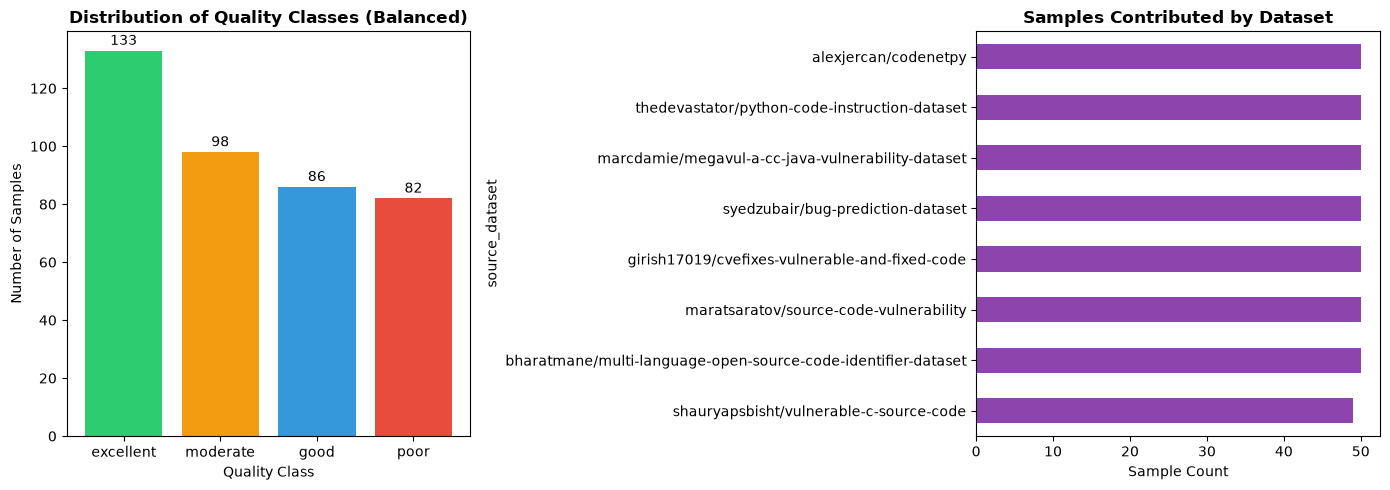

Class Breakdown Table:


,Sample Count
label,
excellent,133
moderate,98
good,86
poor,82


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Plot 1: Target Class Distribution
plt.subplot(1, 2, 1)
colors = {"excellent": "#2ecc71", "good": "#3498db", "moderate": "#f39c12", "poor": "#e74c3c"}
class_counts = df_preprocessed["label"].value_counts()
bars = plt.bar(class_counts.index, class_counts.values, color=[colors.get(k, "#95a5a6") for k in class_counts.index])
plt.title("Distribution of Quality Classes (Balanced)", fontsize=12, fontweight="bold")
plt.xlabel("Quality Class")
plt.ylabel("Number of Samples")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(int(bar.get_height())), ha="center")

# Plot 2: Source Dataset Contributions
plt.subplot(1, 2, 2)
df_preprocessed["source_dataset"].value_counts().plot(kind="barh", color="#8e44ad")
plt.title("Samples Contributed by Dataset", fontsize=12, fontweight="bold")
plt.xlabel("Sample Count")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Summary table
print("Class Breakdown Table:")
display(df_preprocessed["label"].value_counts().to_frame("Sample Count"))

### Cell 8: Save Pre-Processed Dataset to Disk
Save the cleaned, standardized feature table to `backend/review_results/preprocessed_benchmark_dataset.csv`.

In [58]:
output_csv = PROJECT_ROOT / "backend" / "review_results" / "preprocessed_benchmark_dataset.csv"
output_csv.parent.mkdir(parents=True, exist_ok=True)
df_preprocessed.to_csv(output_csv, index=False)

print(f"Saved preprocessed dataset to:\n{output_csv}")
print(f"Total Rows: {len(df_preprocessed)} | Columns: {len(df_preprocessed.columns)}")

Saved preprocessed dataset to:
D:\VS Code\Structured Projects\Ai Project Reviewer\backend\review_results\preprocessed_benchmark_dataset.csv
Total Rows: 399 | Columns: 18


---
## 🛑 PRE-PROCESSING COMPLETE: USER REVIEW CHECKPOINT

**As requested:** Pre-processing is now finished and the dataset is structured, cleaned, and verified.

Please review the summary metrics above. When you are ready to train the model, run **Cell 9** below!

### Cell 9: Feature Scaling, 3-Way Partitioning & Production Pipeline Training
Applies **Feature Scaling (`StandardScaler`)** within a Scikit-Learn `Pipeline` across the 3 partitioned buckets (70% Train, 15% Val, 15% Test) to standardize feature ranges and prevent data leakage.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from backend.app.training.trainer import FEATURES
import joblib

# 1. Feature Engineering: 15 standard numerical code quality metrics
X = df_preprocessed[FEATURES]
y = df_preprocessed["label"]

# 2. Partitioning into 3 distinct buckets (70% Train / 15% Val / 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[*] Dataset Split Complete:")
print(f"    -> Training Set:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"    -> Validation Set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"    -> Test Set:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# 3. Feature Scaling & Hyperparameter Tuning on Validation Set
#    StandardScaler normalizes all 15 features to zero mean and unit variance
print("\n[*] Hyperparameter Tuning with Feature Scaling (StandardScaler):")
best_depth = None
best_val_acc = -1.0
best_pipeline = None

for depth in [4, 6, 8, 10, None]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42))
    ])
    pipeline.fit(X_train, y_train)
    val_acc = pipeline.score(X_val, y_val)
    depth_label = f"{depth}" if depth is not None else "None (unlimited)"
    print(f"    max_depth={depth_label:<16} | Validation Accuracy: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_depth = depth
        best_pipeline = pipeline

print(f"\n[+] Best Pipeline Selected: max_depth={best_depth} (Validation Accuracy: {best_val_acc:.4f})")

# 4. Final Unbiased Benchmark on Isolated Test Set
y_test_pred = best_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\n=== FINAL ISOLATED TEST SET BENCHMARK (WITH SCALING) ===")
print(f"Test Set Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_test_pred))

# 5. Persist Production Pipeline (Includes fitted Scaler + Random Forest)
model_path = PROJECT_ROOT / "backend" / "models" / "quality_model.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipeline, model_path)
print(f"[+] Production Pipeline saved to: {model_path}")


[*] Dataset Split Complete:
    -> Training Set:   279 samples (69.9%)
    -> Validation Set: 60 samples (15.0%)
    -> Test Set:       60 samples (15.0%)

[*] Hyperparameter Tuning with Feature Scaling (StandardScaler):
    max_depth=4                | Validation Accuracy: 0.6833
    max_depth=6                | Validation Accuracy: 0.6500
    max_depth=8                | Validation Accuracy: 0.6167
    max_depth=10               | Validation Accuracy: 0.6167
    max_depth=None (unlimited) | Validation Accuracy: 0.6000

[+] Best Pipeline Selected: max_depth=4 (Validation Accuracy: 0.6833)

=== FINAL ISOLATED TEST SET BENCHMARK (WITH SCALING) ===
Test Set Accuracy: 0.6333

              precision    recall  f1-score   support

   excellent       0.57      0.85      0.68        20
        good       0.00      0.00      0.00        13
    moderate       0.72      0.87      0.79        15
        poor       0.89      0.67      0.76        12

    accuracy                           0.63   

### Cell 10: Deep Learning (Neural Network) Core Training Loop & Loss Curve
Demonstrates the **4-Phase Deep Learning Loop**:
1. **Forward Pass (Prediction)**: 15 scaled inputs $\rightarrow$ Hidden Layer 1 (32 ReLU) $\rightarrow$ Hidden Layer 2 (16 ReLU) $\rightarrow$ Softmax (4 classes).
2. **Loss Function (Error Measurement)**: Categorical Cross-Entropy Loss evaluates prediction errors.
3. **Backpropagation**: Calculates partial derivatives (gradients) using the Chain Rule.
4. **Optimizer**: **Adam (Adaptive Gradient Descent)** updates weights each epoch to minimize loss.

Plots the **Epoch vs. Loss Reduction Curve** to visualize how the error shrinks over 150 training cycles.

[*] Training Neural Network across 200 Epochs (Forward -> Loss -> Backprop -> Adam)...
[+] Completed 200 Epochs!
    -> Initial Loss (Epoch 1):   1.4247
    -> Final Loss (Epoch 200):   0.2557
    -> Total Error Reduction:    82.1%


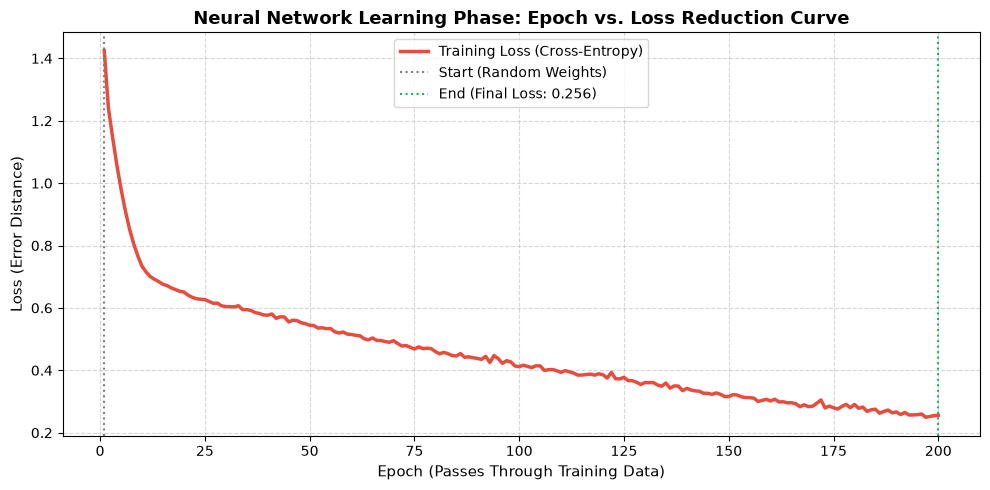

=== NEURAL NETWORK TEST SET PERFORMANCE ===
Test Set Accuracy: 0.5833 (58.3%)

              precision    recall  f1-score   support

   excellent       0.59      0.80      0.68        20
        good       0.22      0.15      0.18        13
    moderate       0.69      0.60      0.64        15
        poor       0.73      0.67      0.70        12

    accuracy                           0.58        60
   macro avg       0.56      0.56      0.55        60
weighted avg       0.56      0.58      0.57        60



In [60]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Feature Scaling for Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Build Multi-Layer Perceptron (Neural Network)
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)

print("[*] Training Neural Network across 200 Epochs (Forward -> Loss -> Backprop -> Adam)...")
mlp.fit(X_train_scaled, y_train)

print(f"[+] Completed {len(mlp.loss_curve_)} Epochs!")
print(f"    -> Initial Loss (Epoch 1):   {mlp.loss_curve_[0]:.4f}")
print(f"    -> Final Loss (Epoch {len(mlp.loss_curve_)}):   {mlp.loss_curve_[-1]:.4f}")
reduction = (mlp.loss_curve_[0] - mlp.loss_curve_[-1]) / mlp.loss_curve_[0] * 100
print(f"    -> Total Error Reduction:    {reduction:.1f}%")

# 3. Plot Epoch vs Loss Reduction Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_, color='#e74c3c', lw=2.5, label='Training Loss (Cross-Entropy)')
plt.title('Neural Network Learning Phase: Epoch vs. Loss Reduction Curve', fontsize=13, fontweight='bold')
plt.xlabel('Epoch (Passes Through Training Data)', fontsize=11)
plt.ylabel('Loss (Error Distance)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(x=1, color='gray', linestyle=':', label='Start (Random Weights)')
plt.axvline(x=len(mlp.loss_curve_), color='#27ae60', linestyle=':', label=f'End (Final Loss: {mlp.loss_curve_[-1]:.3f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 4. Evaluate on Isolated Test Set
mlp_test_pred = mlp.predict(X_test_scaled)
mlp_test_acc = accuracy_score(y_test, mlp_test_pred)
print(f"=== NEURAL NETWORK TEST SET PERFORMANCE ===")
print(f"Test Set Accuracy: {mlp_test_acc:.4f} ({mlp_test_acc*100:.1f}%)\n")
print(classification_report(y_test, mlp_test_pred))


### Cell 11: Final Evaluation & Testing on Isolated Test Data
Provides an **unbiased audit** of the trained production pipeline on the 15% isolated Test Set (60 samples):
1. **Confusion Matrix Heatmap**: Visualizes true vs. predicted classifications across all 4 quality tiers.
2. **Feature Importance Ranking**: Explains which code quality signals (security, bug risks, error counts) drive the model's decisions.

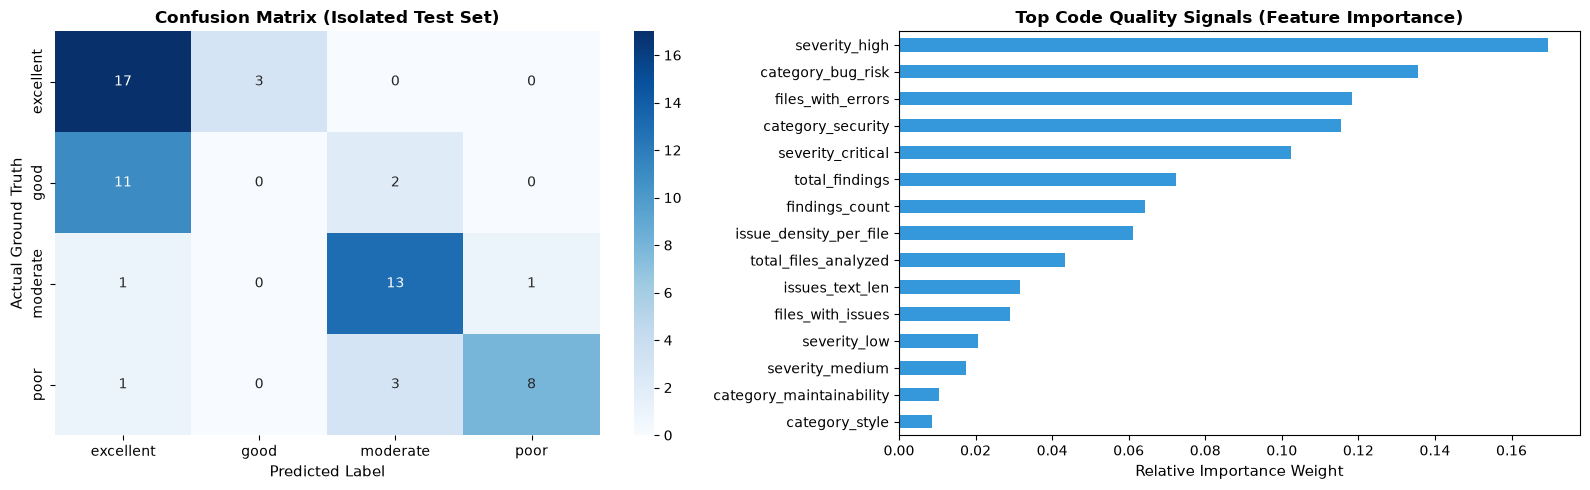

=== FINAL AUDIT REPORT ON UNSEEN TEST DATA ===
Overall Test Accuracy: 63.3%

              precision    recall  f1-score   support

   excellent       0.57      0.85      0.68        20
        good       0.00      0.00      0.00        13
    moderate       0.72      0.87      0.79        15
        poor       0.89      0.67      0.76        12

    accuracy                           0.63        60
   macro avg       0.54      0.60      0.56        60
weighted avg       0.55      0.63      0.58        60



In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Predict on the isolated 60-sample Test Set using the saved Production Pipeline
y_test_pred = best_pipeline.predict(X_test)
classes = ['excellent', 'good', 'moderate', 'poor']
cm = confusion_matrix(y_test, y_test_pred, labels=classes)

# 2. Plot Confusion Matrix Heatmap & Feature Importance Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('Confusion Matrix (Isolated Test Set)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('Actual Ground Truth', fontsize=11)

# Subplot 2: Feature Importance Ranking
rf_model = best_pipeline.named_steps['classifier']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', color='#3498db', ax=ax2)
ax2.set_title('Top Code Quality Signals (Feature Importance)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Relative Importance Weight', fontsize=11)

plt.tight_layout()
plt.show()

# 3. Print Final Performance Summary
print('=== FINAL AUDIT REPORT ON UNSEEN TEST DATA ===')
print(f'Overall Test Accuracy: {accuracy_score(y_test, y_test_pred)*100:.1f}%\n')
print(classification_report(y_test, y_test_pred, target_names=classes))
